In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, roc_curve, auc

In [ ]:
# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

print(X.head())
print("Dataset shape:", X.shape)

   radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3    11.42     20.38       77.58   386.1      0.14250       0.28390   
4    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...  radius3  \
0      0.3001          0.14710     0.2419             0.07871  ...    25.38   
1      0.0869          0.07017     0.1812             0.05667  ...    24.99   
2      0.1974          0.12790     0.2069             0.05999  ...    23.57   
3      0.2414          0.10520     0.2597             0.09744  ...    14.91   
4      0.1980          0.10430     0.1809             0.05883  ...    22.54   

   texture3  perimeter3   area3  smoothness3  compactness3  concavity3  \
0     17.33      184.60 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (455, 30)
Testing data shape: (114, 30)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Experiment-6


In [ ]:
#Train KNN Model
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier()

In [ ]:
#Predict Test Data
knn_pred = knn.predict(X_test)

KNN Accuracy: 0.9473684210526315


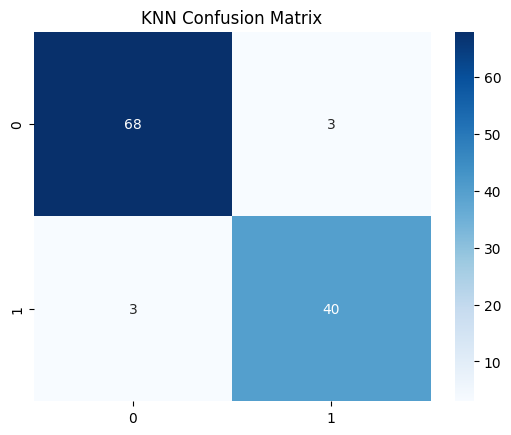

              precision    recall  f1-score   support

           B       0.96      0.96      0.96        71
           M       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



ValueError: y_true takes value in {'B', 'M'} and pos_label is not specified: either make y_true take value in {0, 1} or {-1, 1} or pass pos_label explicitly.

In [ ]:
#Evaluate KNN Model
#Accuracy
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
#Confusion Matrix
cm_knn = confusion_matrix(y_test, knn_pred)
sns.heatmap(cm_knn, annot=True, cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.show()
#Classification Report
print(classification_report(y_test, knn_pred))
#Precision Recall Curve
y_prob_knn = knn.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_prob_knn)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("KNN Precision Recall Curve")
plt.show()

# Experiment-7


In [ ]:
#Train SVM Model
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(kernel='linear', probability=True)

In [ ]:
#Predict Test Data
svm_pred = svm.predict(X_test)

SVM Accuracy: 0.956140350877193


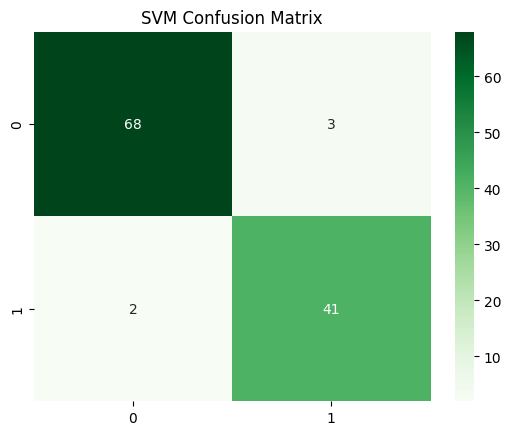

              precision    recall  f1-score   support

           B       0.97      0.96      0.96        71
           M       0.93      0.95      0.94        43

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



ValueError: y_true takes value in {'B', 'M'} and pos_label is not specified: either make y_true take value in {0, 1} or {-1, 1} or pass pos_label explicitly.

In [ ]:
#Evaluate SVM Model
#Accuracy
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
#Confusion Matrix
cm_svm = confusion_matrix(y_test, svm_pred)
sns.heatmap(cm_svm, annot=True, cmap="Greens")
plt.title("SVM Confusion Matrix")
plt.show()
#Classification Report
print(classification_report(y_test, svm_pred))
#Precision Recall Curve
y_prob_svm = svm.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_prob_svm)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("SVM Precision Recall Curve")
plt.show()

# Experiment-8

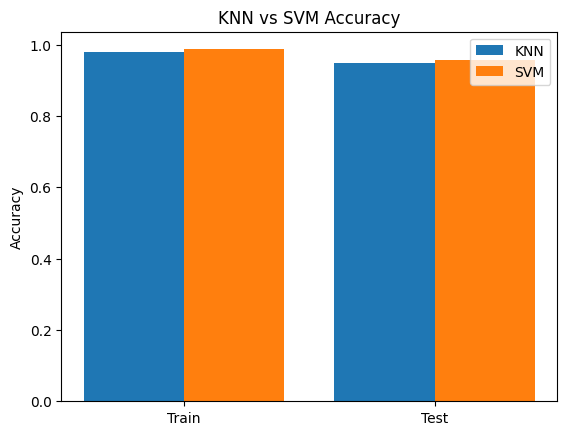

In [ ]:
#Accuracy Comparison Bar Chart
train_knn = knn.score(X_train, y_train)
test_knn = knn.score(X_test, y_test)

train_svm = svm.score(X_train, y_train)
test_svm = svm.score(X_test, y_test)

labels = ["Train", "Test"]

knn_scores = [train_knn, test_knn]
svm_scores = [train_svm, test_svm]

x = np.arange(len(labels))

plt.bar(x-0.2, knn_scores, 0.4, label="KNN")
plt.bar(x+0.2, svm_scores, 0.4, label="SVM")

plt.xticks(x, labels)
plt.ylabel("Accuracy")
plt.title("KNN vs SVM Accuracy")
plt.legend()

plt.show()

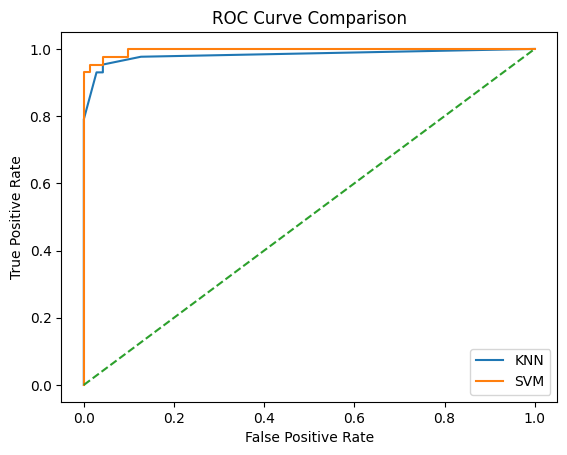

In [ ]:
#ROC Curve Comparison
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn, pos_label='M')
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm, pos_label='M')

plt.plot(fpr_knn, tpr_knn, label="KNN")
plt.plot(fpr_svm, tpr_svm, label="SVM")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

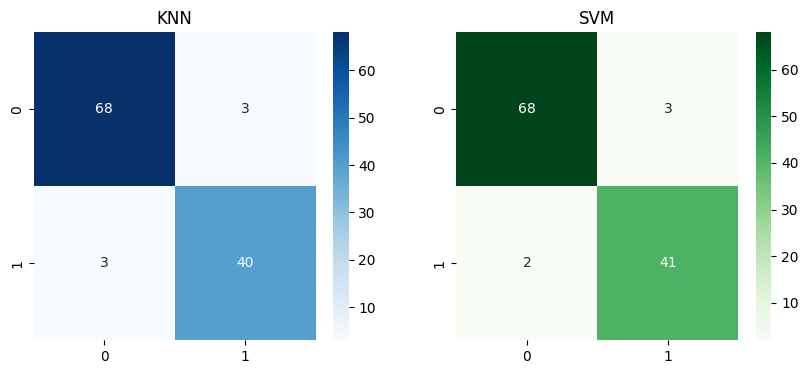

In [ ]:
#Confusion Matrix Comparison
fig, ax = plt.subplots(1,2, figsize=(10,4))

sns.heatmap(cm_knn, annot=True, ax=ax[0], cmap="Blues")
ax[0].set_title("KNN")

sns.heatmap(cm_svm, annot=True, ax=ax[1], cmap="Greens")
ax[1].set_title("SVM")

plt.show()